In [1]:
# Acesso à raiz do projeto

import sys
import os

# Caminho até a raiz do projeto
sys.path.append(os.path.abspath("../../"))


In [2]:
# Importação das bibliotecas necessárias

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from modulos.gerais import exibir_resultado, exibir_relatorio_de_classificacao, preparar_iris
from modulos.knn import preparar_knn, treinar_k, atualizar_melhor_desempenho_k, exibir_melhor_resultado_do_knn, exibir_grafico_comparativo


In [3]:
# Importação e exploração dos dados
iris = load_iris()
X, y, feature_names, target_names = preparar_iris(iris)

# Divisão em Treino (70%) e Teste (30%) com semente fixa para reprodutibilidade
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=13, stratify=y
)


In [4]:
# Estabelecendo as variáveis que serão usadas no loop do KNN
valores_k, resultados_acuracia, melhor_k, melhor_f1 = preparar_knn()


In [5]:
for k in valores_k:
    # Treinando e avaliando o modelo de acordo com o K atual
    acuracia_knn, precisao_knn, revocacao_knn, f1_knn = treinar_k(
        k, resultados_acuracia, X_train, y_train, X_test, y_test
    )

    # Exibindo o resultado do K atual
    exibir_resultado(
        acuracia_knn, precisao_knn, revocacao_knn, f1_knn,
        f"KNN (K = {k})"
    )

    # Atualizando qual é o melhor modelo baseado no F1-Score
    melhor_f1, melhor_k = atualizar_melhor_desempenho_k(f1_knn, k, melhor_f1, melhor_k)

exibir_melhor_resultado_do_knn(melhor_k, melhor_f1)


MÉTRICAS DE AVALIAÇÃO - KNN (K = 1)
Acurácia:  0.9778
Precisão:  0.9792
Revocação: 0.9778
F1-Score:  0.9778


MÉTRICAS DE AVALIAÇÃO - KNN (K = 3)
Acurácia:  0.9778
Precisão:  0.9792
Revocação: 0.9778
F1-Score:  0.9778


MÉTRICAS DE AVALIAÇÃO - KNN (K = 5)
Acurácia:  0.9778
Precisão:  0.9792
Revocação: 0.9778
F1-Score:  0.9778


MÉTRICAS DE AVALIAÇÃO - KNN (K = 7)
Acurácia:  0.9778
Precisão:  0.9792
Revocação: 0.9778
F1-Score:  0.9778


MÉTRICAS DE AVALIAÇÃO - KNN (K = 9)
Acurácia:  0.9778
Precisão:  0.9792
Revocação: 0.9778
F1-Score:  0.9778


MÉTRICAS DE AVALIAÇÃO - KNN (K = 11)
Acurácia:  1.0000
Precisão:  1.0000
Revocação: 1.0000
F1-Score:  1.0000


CONCLUSÃO: O melhor desempenho foi com K = 11 (F1-Score: 1.0000)


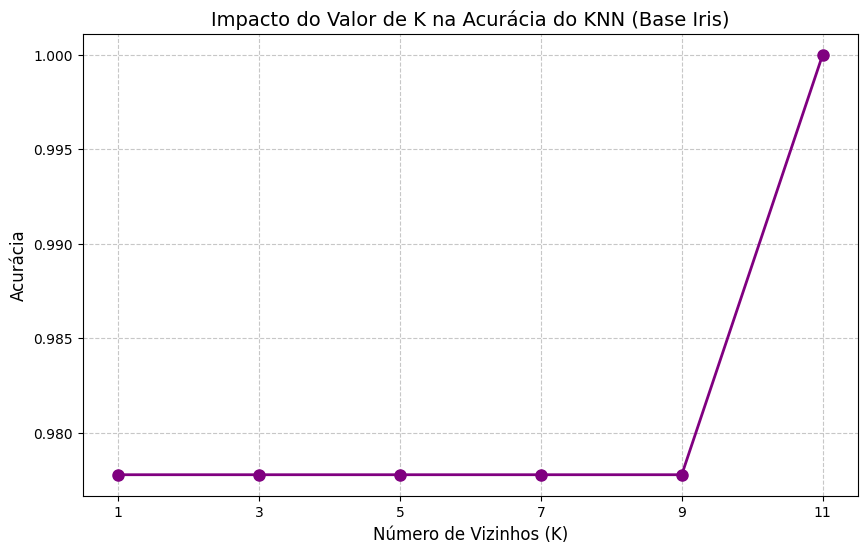

In [6]:
# Representação gráfica dos valores de K usados no KNN
exibir_grafico_comparativo(valores_k, resultados_acuracia, "Iris")
